# Comparative Analysis of the Lotka-Volterra System

This notebook presents a comprehensive comparative analysis of the Lotka-Volterra predator-prey model. The study bridges classical dynamical systems theory with modern computational approaches, exploring the system from three complementary perspectives:

1. **Mathematical Properties**: Analysis of equilibria, linearization, and invariant quantities.
2. **Numerical Stability**: Evaluation of explicit solvers (Euler, RK2, RK4) and their geometric properties over time.
3. **Machine Learning Dynamics**: A comparative evaluation of purely data-driven models (Baseline NN, ResNet) against physics-informed approaches (PINNs, Neural ODEs).

All figures and datasets referenced in this notebook are generated via the reproducible pipeline defined in `run_analysis.py`.

In [6]:
from pathlib import Path
import csv
import sys
from IPython.display import Image, display

for module_name in list(sys.modules):
    if module_name == "src" or module_name.startswith("src."):
        del sys.modules[module_name]

from src.experiments import format_metrics_table, system_summary
from src.solvers import LotkaVolterraParams

results_dir = Path("results")
if not results_dir.exists():
    raise FileNotFoundError("results/ not found. Run `python run_analysis.py` first.")

def load_csv(path):
    with path.open("r", encoding="utf-8") as handle:
        rows = list(csv.DictReader(handle))
    for row in rows:
        for key, value in list(row.items()):
            try:
                row[key] = float(value)
            except (TypeError, ValueError):
                row[key] = value
    return rows

def show_image(name, width=950):
    path = results_dir / name
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        print(f"Missing image: {path}")

params = LotkaVolterraParams(alpha=1.0, beta=1.0, gamma=1.0, delta=1.0)
solver_rows = load_csv(results_dir / "solver_metrics.csv")
ml_rows = load_csv(results_dir / "ml_metrics.csv")

print("Using results from:", results_dir.resolve())

Using results from: C:\Users\jerry\Desktop\Winter2026\495\FinalProject\results


## 1. Mathematical and Qualitative Analysis

The Lotka-Volterra system is defined by the following nonlinear ordinary differential equations:

$$
\frac{dx}{dt} = \alpha x - \beta x y, \qquad \frac{dy}{dt} = \delta x y - \gamma y
$$

For our standard configuration ($\alpha = \beta = \gamma = \delta = 1$), the non-trivial coexistence equilibrium point is located at $(x^*, y^*) = (1, 1)$. To understand the local dynamics near this coexistence state, we compute the Jacobian matrix:

$$
J(x,y)=
\begin{bmatrix}
\alpha-\beta y & -\beta x \\
\delta y & \delta x - \gamma
\end{bmatrix}
$$

Evaluating the Jacobian at $(1, 1)$ yields eigenvalues $\lambda = \pm i\sqrt{\alpha\gamma} = \pm i$. The purely imaginary eigenvalues indicate that the linearized system acts as a **center**. Consequently, the trajectories form closed orbits (limit cycles are absent), meaning the populations will oscillate continuously without damping.

Furthermore, this continuous oscillation implies the existence of a conserved quantity (a Hamiltonian-like invariant) for the system:

$$
H(x,y) = \delta x - \gamma \ln x + \beta y - \alpha \ln y
$$

Along any solution trajectory, $\frac{dH}{dt} = 0$. This invariant property serves as a critical benchmark for evaluating both our numerical solvers and machine learning models.

In [7]:
system_summary(params)

{'equilibria': {'origin': [0.0, 0.0], 'coexistence': [1.0, 1.0]},
 'coexistence_eigenvalues': ['1j', '-1j'],
 'nullclines': {'dx_dt_zero_y': 1.0, 'dy_dt_zero_x': 1.0},
 'small_oscillation_period': 6.283185307179586}

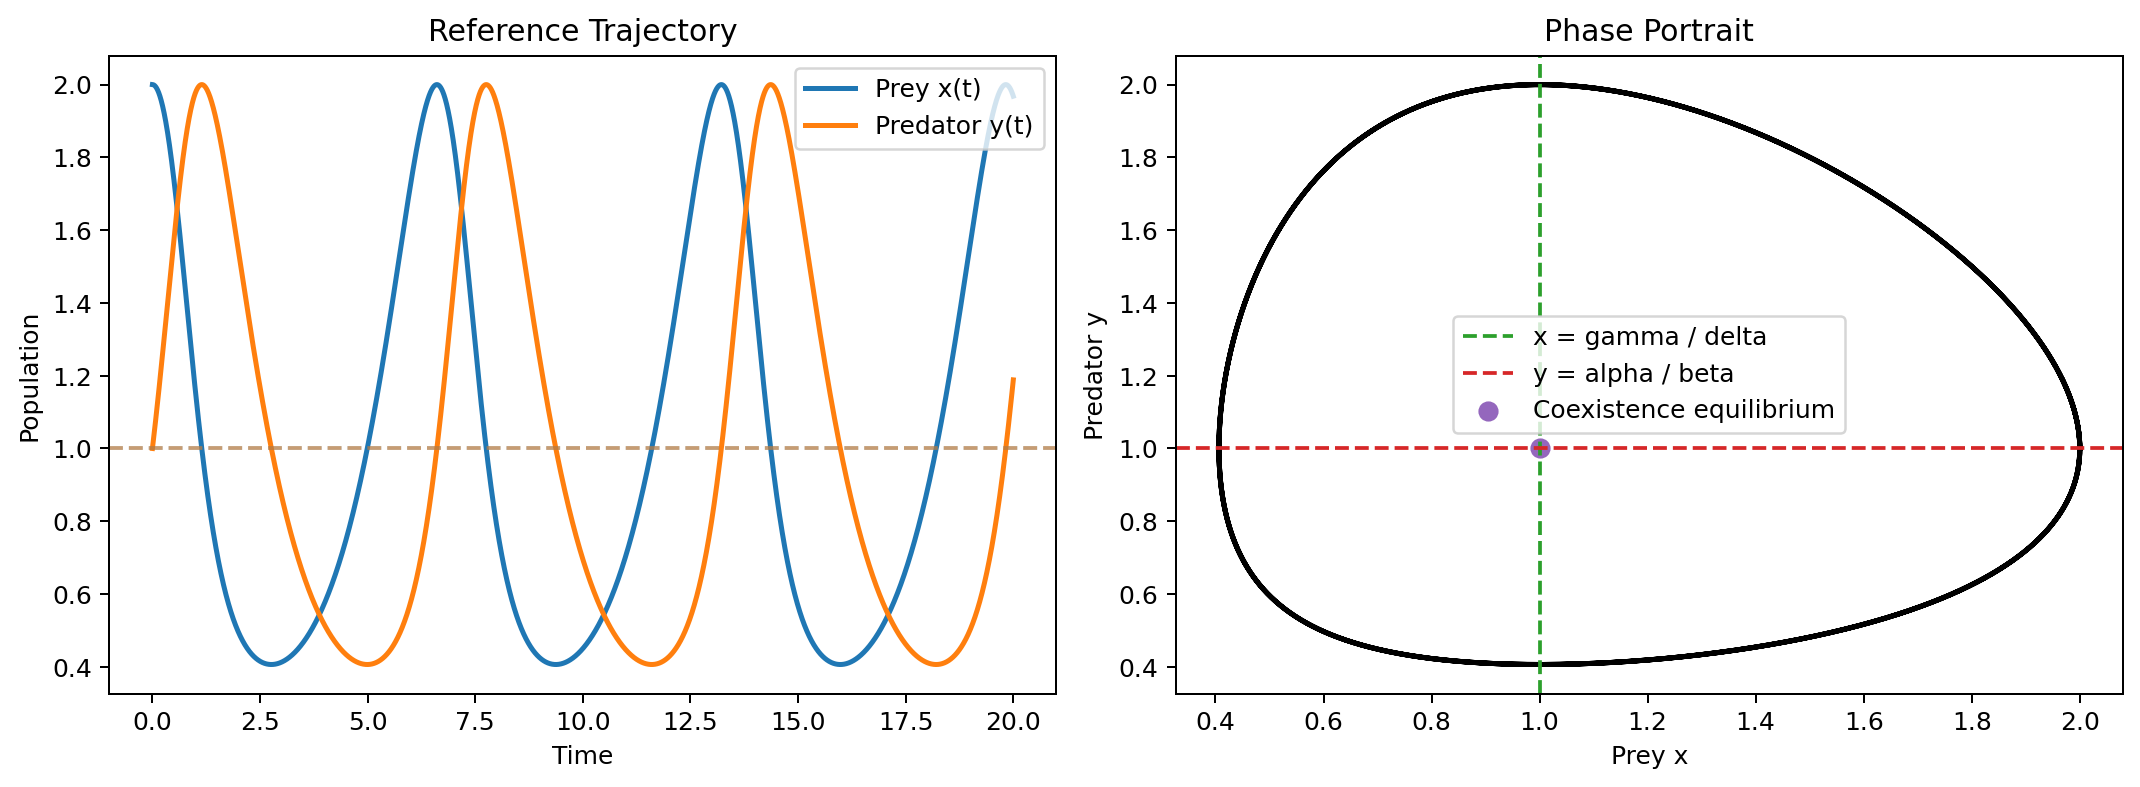

In [8]:
show_image("reference_trajectory.png", width=1100)

## 2. Analytical solutions

This system does **not** have a simple explicit elementary closed-form solution $x(t), y(t)$ in general. However, it does have a very important analytical structure: a conserved quantity.

Starting from

$$
\frac{dy}{dx}=\frac{dy/dt}{dx/dt}=\frac{y(\delta x-\gamma)}{x(\alpha-\beta y)},
$$

we separate variables:

$$
\left(\frac{\alpha-\beta y}{y}\right)dy = \left(\frac{\delta x-\gamma}{x}\right)dx.
$$

Integrating gives

$$
\alpha \ln y - \beta y = \delta x - \gamma \ln x + C,
$$

which can be rearranged as

$$
H(x,y)=\delta x-\gamma\ln x+\beta y-\alpha\ln y=C.
$$

This is the analytical result used throughout the project. It means:

- trajectories stay on level sets of $H(x,y)$,
- the system has closed phase-plane orbits in the positive quadrant,
- numerical solvers can be judged by how much they drift away from this conserved quantity,
- learned trajectories can also be judged by whether they preserve this structure.

So the analytical-solution discussion in this system is not an explicit formula for $x(t)$ and $y(t)$, but rather the conserved quantity that captures the geometry of the true dynamics.

## 3. Study numerical stability, compare different numerical solvers

This section uses the actual outputs in `results/solver_metrics.csv`.

The strongest pattern is that **Euler is much less stable than RK2 and RK4**.

- At `dt = 0.2`, Euler has `max_state_error = 12.5206`, `final_state_error = 2.0003`, `max_invariant_drift = 6.9506`, and even `8` positivity violations. That is a clear sign that the numerical trajectory is no longer respecting the geometry of the physical solution.
- When Euler is refined to `dt = 0.025`, the error drops, but it is still much worse than higher-order methods: `max_state_error = 0.5248` and `max_invariant_drift = 0.1882`.

**RK2 is a major improvement over Euler.**

- At `dt = 0.1`, RK2 reduces `max_state_error` from Euler's `2.4497` down to `0.0323`.
- At the same `dt = 0.1`, invariant drift drops from Euler's `1.6054` to only `0.001866`.
- This shows that a second-order method already preserves the orbit structure far better than first-order Euler.

**RK4 is by far the most accurate solver in this study.**

- At `dt = 0.1`, RK4 gives `max_state_error = 1.44e-05` and `max_invariant_drift = 1.57e-06`.
- Even at `dt = 0.2`, RK4 remains extremely accurate: `max_state_error = 2.18e-04` and `max_invariant_drift = 3.16e-05`.
- At `dt = 0.025`, the errors are essentially at the numerical-reference level.

So the numerical-stability conclusion is straightforward:

- Euler is fast but qualitatively unreliable for this oscillatory system at coarse step sizes.
- RK2 is a strong middle ground.
- RK4 is the best method here if accuracy and structure preservation matter more than raw speed.

For this project, the conserved quantity is especially useful because it shows that the issue is not just pointwise error: unstable methods also distort the phase portrait itself.

In [9]:
print(
    format_metrics_table(
        solver_rows,
        ["method", "dt", "max_state_error", "final_state_error", "max_invariant_drift", "runtime_seconds"],
    )
)

| method | dt | max_state_error | final_state_error | max_invariant_drift | runtime_seconds |
| --- | --- | --- | --- | --- | --- |
| euler | 0.200000 | 12.520597 | 2.000322 | 6.950591 | 0.000590 |
| euler | 0.100000 | 2.449670 | 1.797598 | 1.605442 | 0.001090 |
| euler | 0.050000 | 0.867033 | 0.854740 | 0.467689 | 0.002587 |
| euler | 0.025000 | 0.524826 | 0.524826 | 0.188184 | 0.004321 |
| rk2 | 0.200000 | 0.123082 | 0.123082 | 0.009007 | 0.001070 |
| rk2 | 0.100000 | 0.032308 | 0.032308 | 0.001866 | 0.002110 |
| rk2 | 0.050000 | 0.008343 | 0.008343 | 0.000508 | 0.004190 |
| rk2 | 0.025000 | 0.002125 | 0.002125 | 0.000132 | 0.008687 |
| rk4 | 0.200000 | 0.000218 | 0.000209 | 0.000032 | 0.002259 |
| rk4 | 0.100000 | 0.000014 | 0.000014 | 0.000002 | 0.004500 |
| rk4 | 0.050000 | 0.000001 | 0.000001 | 0.000000 | 0.009409 |
| rk4 | 0.025000 | 0.000000 | 0.000000 | 0.000000 | 0.020101 |


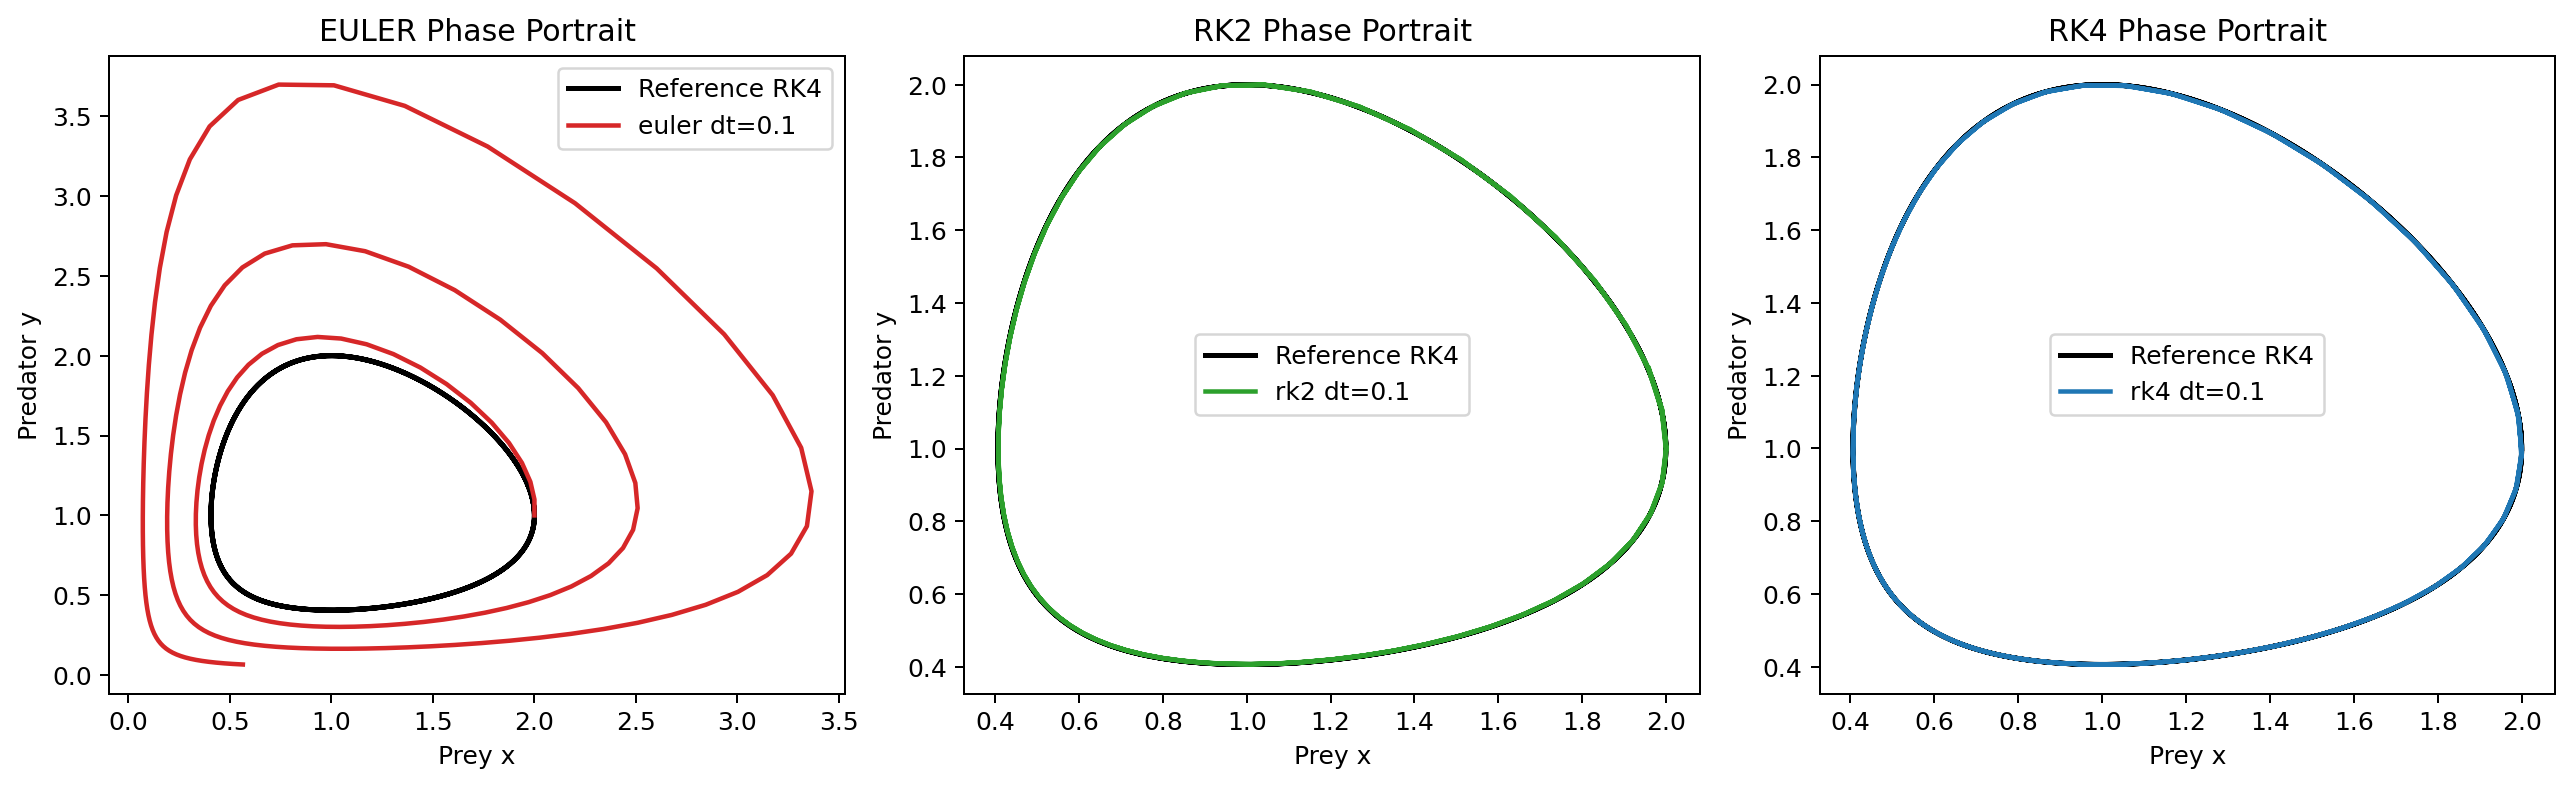

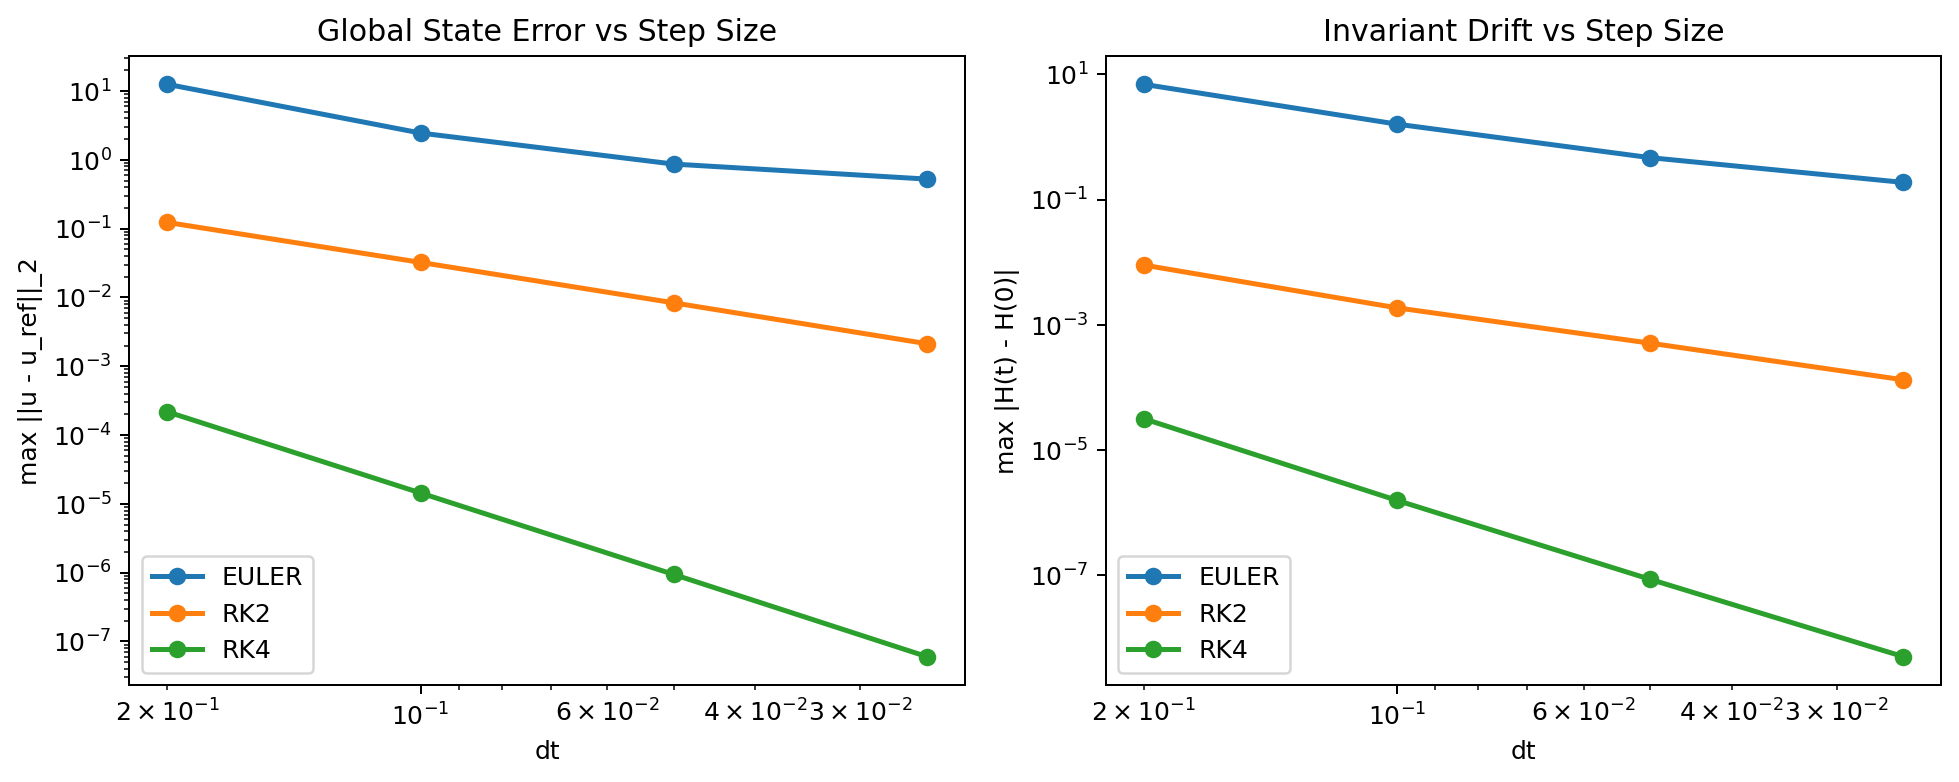

In [10]:
show_image("solver_phase_portraits.png", width=1200)
show_image("solver_error_curves.png", width=1100)

## 4. Compare different machine learning approaches

**Baseline NN**

- `train_rmse = 0.0257`, so it fits the observed training window reasonably well.
- But `extrap_rmse = 1.8982`, `final_state_error = 2.3295`, and `max_invariant_drift = 2.6943` are all poor.
- Interpretation: direct time-to-state regression can memorize the seen portion of the trajectory but does not preserve the dynamics well outside the training window.

**ResNet**

- It has the best interpolation performance: `train_rmse = 0.003717`.
- It also improves extrapolation over the baseline, with `extrap_rmse = 1.2728`.
- Its invariant drift `0.9320` is much better than the baseline's `2.6943`, so residual structure helps optimization and qualitative faithfulness.

**PINN**

- Its training error is worse than the pure data-driven models: `train_rmse = 0.1756`.
- But the extrapolation error `1.0711` is better than both Baseline NN and ResNet.
- This is consistent with the purpose of a PINN: it gives up some interpolation accuracy to enforce the governing ODE, which can help long-horizon behavior.

Note: The PINN is implemented not as a separate model class, but via a custom loss function (_compute_pinn_loss in train.py) applied to the Baseline NN architecture.

**Neural ODE**

- It has the worst training-window fit: `train_rmse = 0.6377`.
- But it has the best extrapolation performance: `extrap_rmse = 0.6842`, the best `final_state_error = 0.8235`, and the lowest invariant drift `0.5612` among the ML models.
- Interpretation: even though it does not overfit the observed points as aggressively, its dynamical inductive bias makes it the most physically reasonable model for forward prediction.

The fundamental difference in the performance of the neural architectures stems from how they conceptualize the time-evolution problem:

* **Baseline NN & ResNet (Purely Data-Driven)**: These models attempt to map the scalar time variable $t$ directly to the state space $(x(t), y(t))$. While ResNet optimizes deeper representations, both struggle severely with extrapolation. They learn specific oscillatory patterns within the training window but fail to capture the underlying vector field, causing rapid divergence once outside the training domain.
* **PINN (Physics-Informed Neural Network)**: By incorporating the ODE residuals into the loss function alongside the data term, the PINN is forced to learn a mapping that not only fits the training points but also respects the local gradient constraints ($\frac{d\hat{x}}{dt} \approx f(\hat{x}, \hat{y})$). This regularization acts as a soft constraint, significantly improving the network's ability to maintain the oscillatory structure during extrapolation.
* **Neural ODE**: Instead of learning the mapping $t \mapsto (x, y)$, the Neural ODE learns the vector field itself: $\frac{d\mathbf{h}(t)}{dt} = f_\theta(\mathbf{h}(t), t)$. By utilizing an underlying ODE solver (e.g., RK4) during both forward passes and backpropagation (via adjoint sensitivity), this architecture intrinsically respects the continuous-time dynamics. It essentially performs system identification, making it the most robust method for predicting long-term behavior and preserving the geometry of the phase space.


In [11]:
print(
    format_metrics_table(
        ml_rows,
        ["model", "train_rmse", "extrap_rmse", "final_state_error", "max_invariant_drift"],
    )
)

| model | train_rmse | extrap_rmse | final_state_error | max_invariant_drift |
| --- | --- | --- | --- | --- |
| Baseline NN | 0.025703 | 1.898206 | 2.329502 | 2.694261 |
| ResNet | 0.003717 | 1.272752 | 1.863631 | 0.932032 |
| PINN | 0.175591 | 1.071082 | 1.981898 | 1.106683 |
| Neural ODE | 0.637722 | 0.684162 | 0.823480 | 0.561198 |


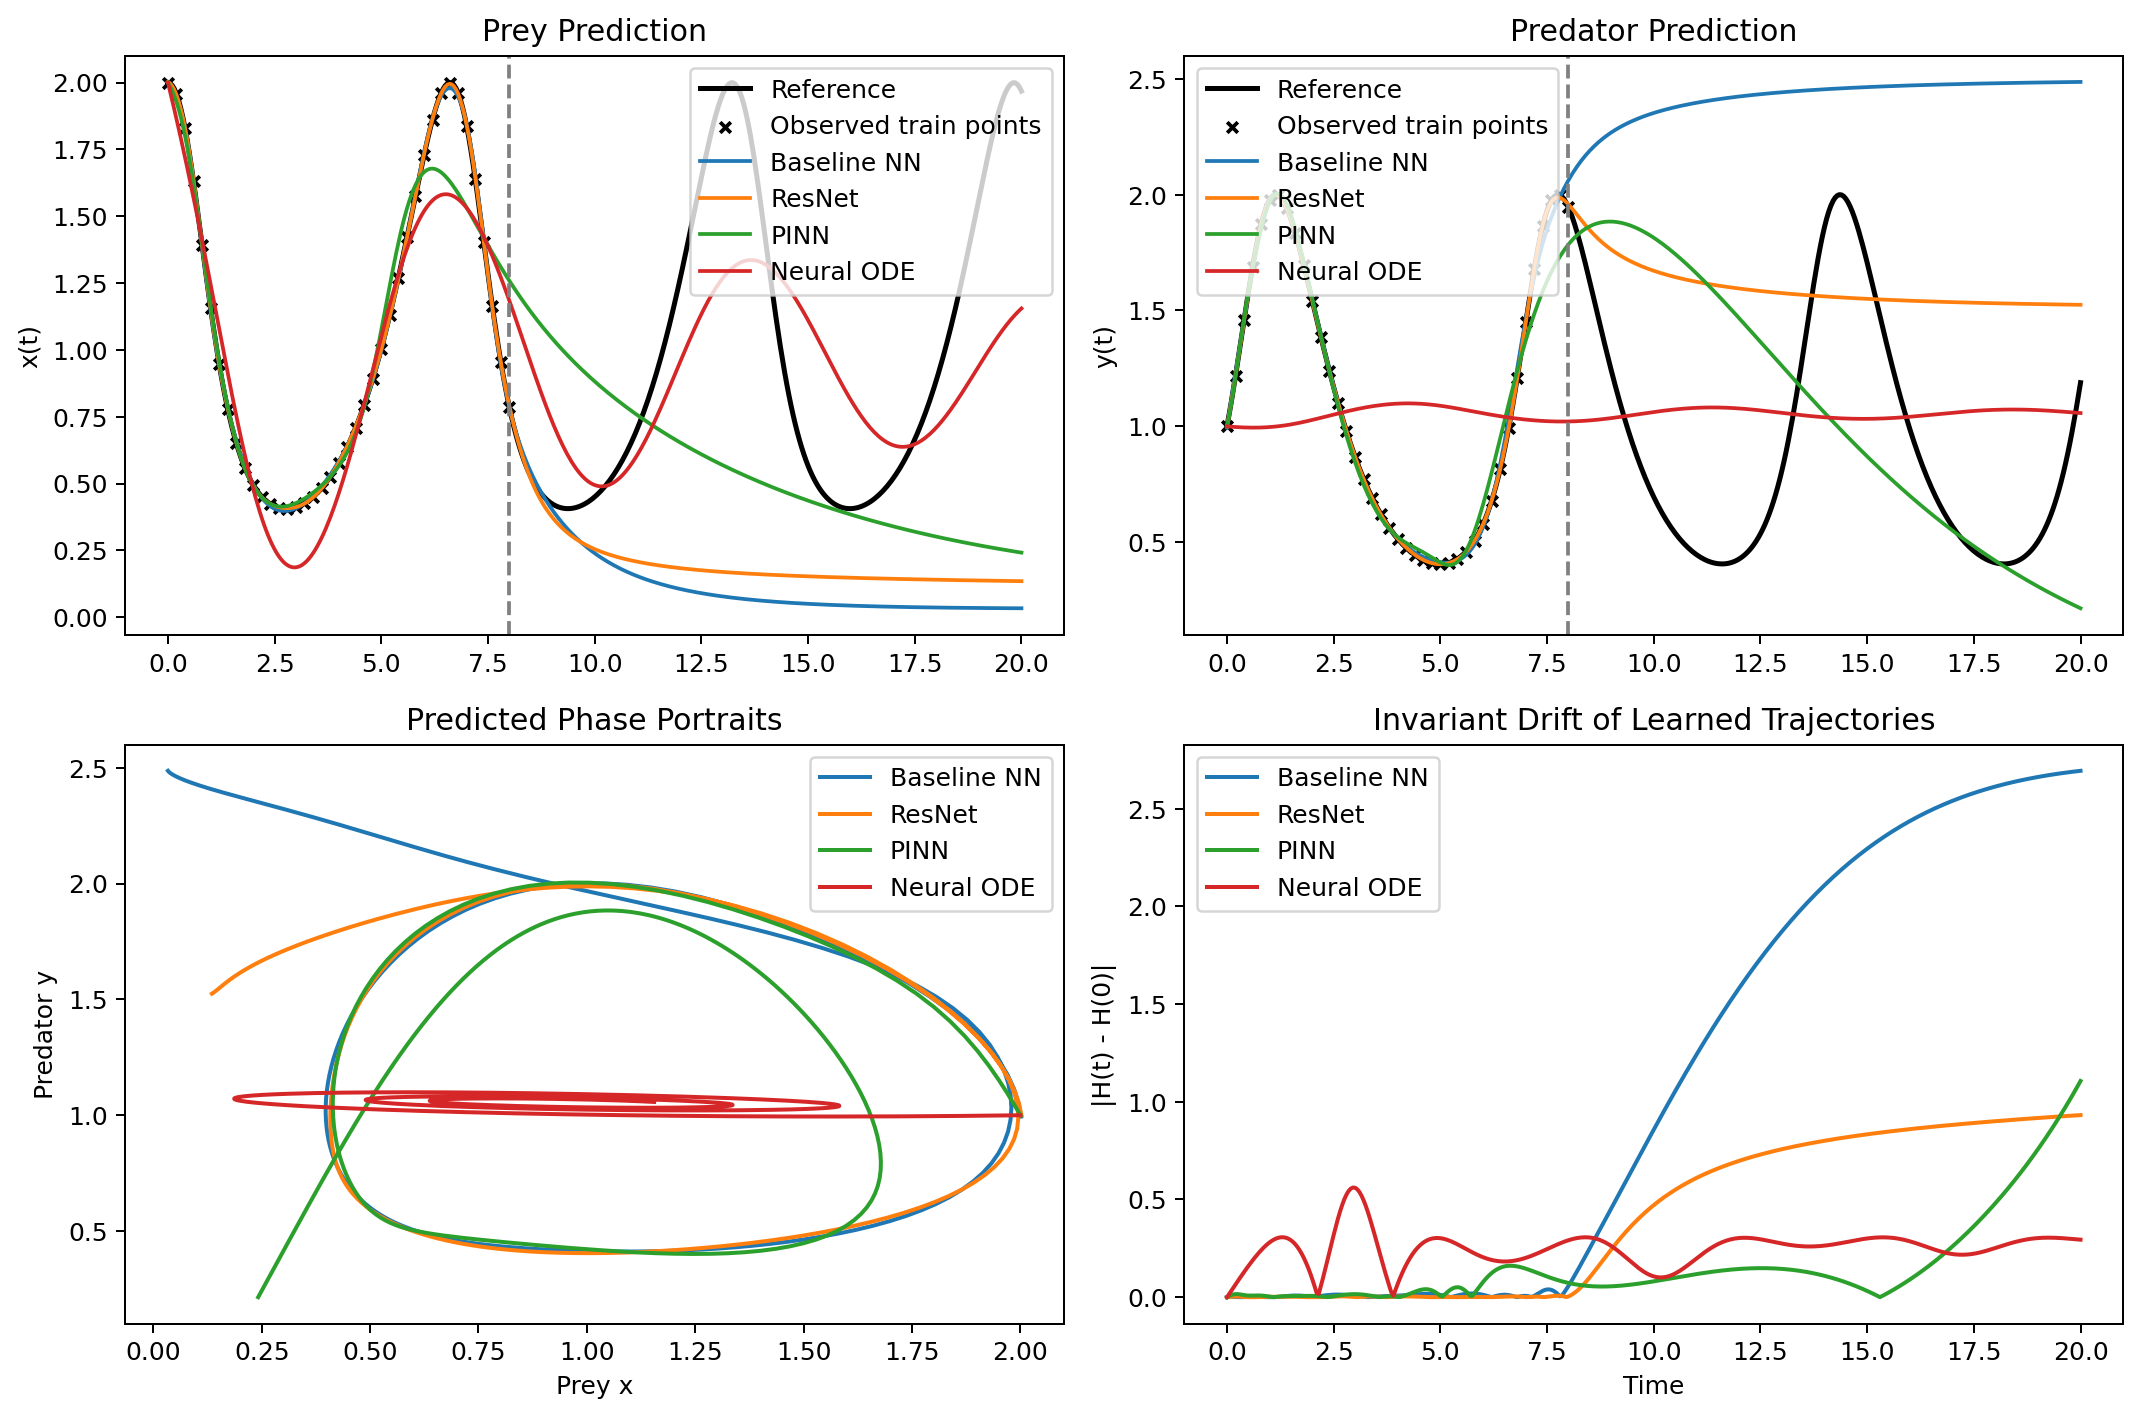

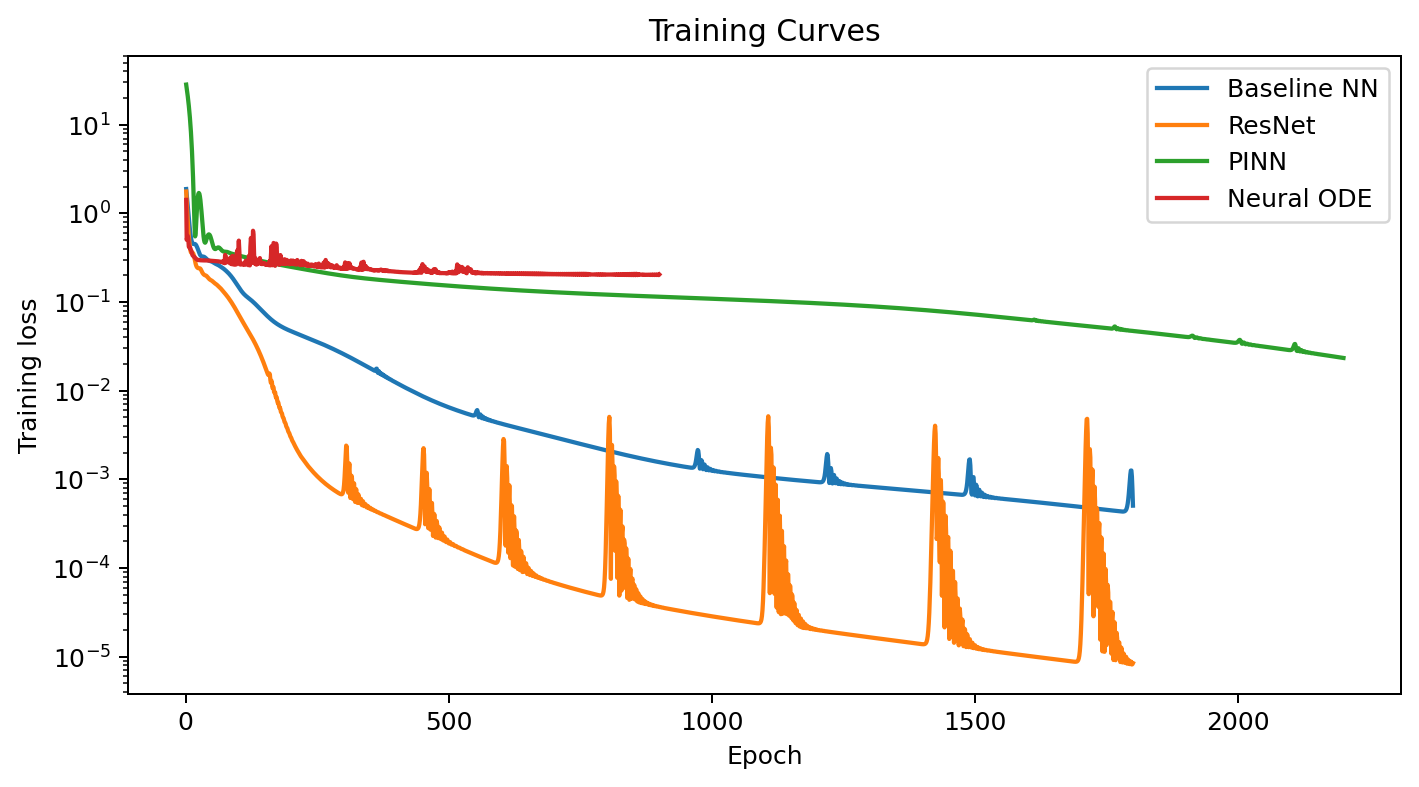

In [12]:
show_image("ml_prediction_comparison.png", width=1200)
show_image("ml_training_curves.png", width=950)